In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

![](https://pavbca.com/walldb/original/9/7/f/456066.jpg)

![](https://i.imgflip.com/36pwb5.jpg)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
train=pd.read_csv('../input/titanic/train.csv')
test=pd.read_csv('../input/titanic/test.csv')

In [4]:
#We will combine train and test data for better Analysis
train['source']='train'
test['source']='test'
test['Survived']=np.NaN

#Concatenating the data in df variable
df=pd.concat([train,test],sort=False,ignore_index=True)

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,source
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,train
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,train
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,train
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,train
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,train


In [6]:
df.shape

(1309, 13)

Dataframe have 1309 rows and 13 columns including the source column

In [7]:
df.nunique()

PassengerId    1309
Survived          2
Pclass            3
Name           1307
Sex               2
Age              98
SibSp             7
Parch             8
Ticket          929
Fare            281
Cabin           186
Embarked          3
source            2
dtype: int64

Survived, Sex, Pclass, SibSp, Parch and Embarked columns have categorical values rest are continuous.


In [8]:
df.isnull().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
source            0
dtype: int64

Age, Fare, Cabin and Embarked have missing values present, while survived have missing values from test set.

In [9]:
df.dtypes

PassengerId      int64
Survived       float64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
source          object
dtype: object

Name, Sex, Ticket, Cabin, Embarked columns are of object type rest of the columns are numerical.

In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,891.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,0.383838,2.294882,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.486592,0.837836,14.413493,1.041658,0.865560,51.758668
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200


Variance of Survived, Pclass, Pclass and Parch column is close to zero. Mean is greater than median in Pclass column, showing that data is skewed towards left, in rest of the columns data is skewed towards right as median is greater. Outliers seem to be present as min interquartile range and maximun ranged do not have same difference.

# EDA

##### Univariate Analysis

<AxesSubplot:xlabel='Survived', ylabel='count'>

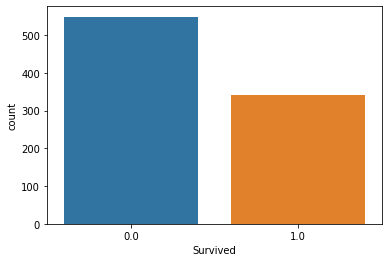

In [11]:
sns.countplot(df['Survived'])

There are more people that have died than people who survived.

<AxesSubplot:xlabel='Pclass', ylabel='count'>

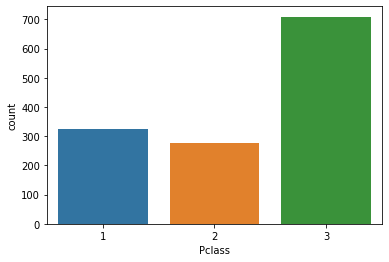

In [12]:
sns.countplot(df['Pclass'])

Most people travelled with 3rd class ticket followed by 1st class the 2nd class

<AxesSubplot:xlabel='Sex', ylabel='count'>

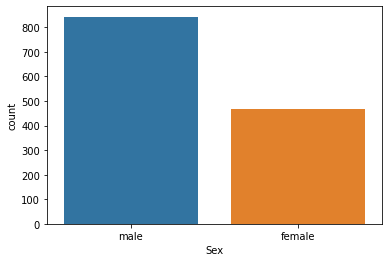

In [13]:
sns.countplot(df['Sex'])

There we almost double the number of male passengers than female

<AxesSubplot:xlabel='Age', ylabel='Count'>

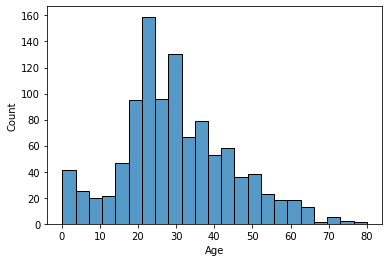

In [14]:
sns.histplot(df['Age'])

People with age between 20 to 30 were the majority among ages, while people also travelled with children of age below 5

<AxesSubplot:xlabel='SibSp', ylabel='count'>

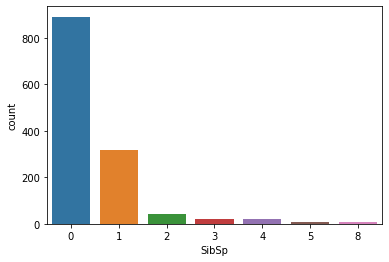

In [15]:
sns.countplot(df['SibSp'])

Mostly siblings or spouses travelling with each passenger were none, one or two but there were passengers present with 8 siblings also.

<AxesSubplot:xlabel='Parch', ylabel='count'>

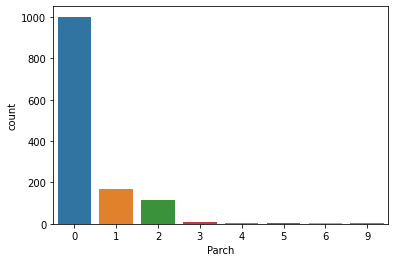

In [16]:
sns.countplot(df['Parch'])

Less than 200 passengers had parents/guardian travelling with them and with some there were 6 guardians with a single child.

<AxesSubplot:xlabel='Fare', ylabel='Density'>

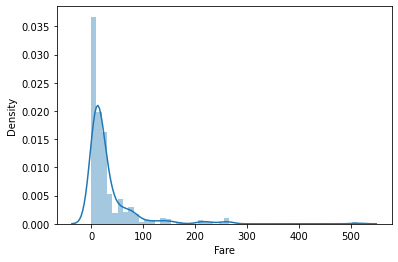

In [17]:
sns.distplot(df['Fare'])

Majority of the people had paid less than 100 for the fare whereas there were elite classes also present who had paid 500.

<AxesSubplot:xlabel='Embarked', ylabel='count'>

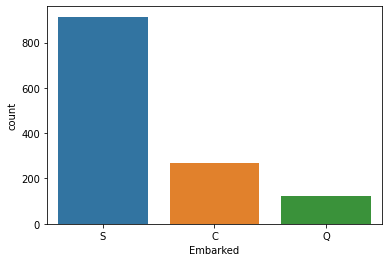

In [18]:
sns.countplot(df['Embarked'])

Most of the people boarded the ship from S harbor followed by C and least from Q

In [19]:
data=df.copy()
data.drop(['PassengerId','Name','Ticket','Cabin','Sex','Embarked','Survived','Pclass','source'],axis=1,inplace=True)
data.head()

,Age,SibSp,Parch,Fare
0,22.0,1,0,7.2500
1,38.0,1,0,71.2833
2,26.0,0,0,7.9250
3,35.0,1,0,53.1000
4,35.0,0,0,8.0500


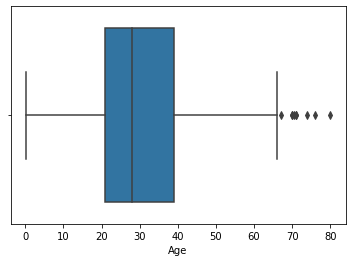

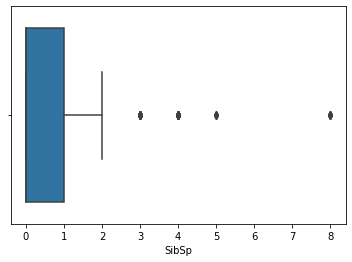

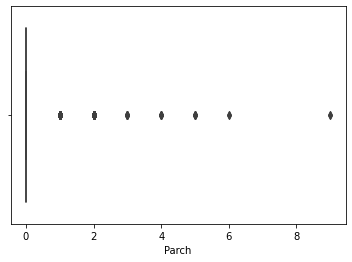

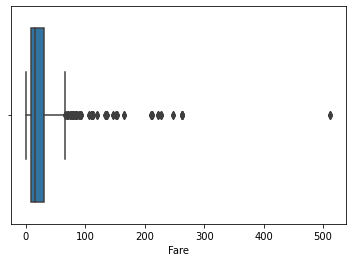

<Figure size 432x288 with 0 Axes>

In [20]:
for i in data.columns:
    sns.boxplot(data[i])
    plt.figure()

A large no. of outliers are present in Fare and Age.

<AxesSubplot:xlabel='Age', ylabel='Density'>

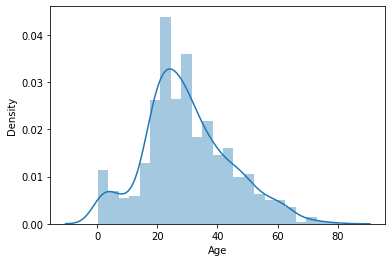

In [21]:
sns.distplot(data['Age'])

Data is almost normally distributed

<AxesSubplot:xlabel='Fare', ylabel='Density'>

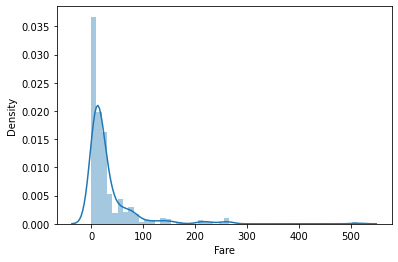

In [22]:
sns.distplot(data['Fare'])

Data skewed to the right

<AxesSubplot:xlabel='Age'>

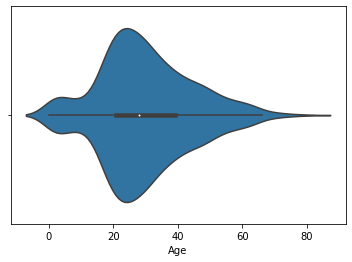

In [23]:
sns.violinplot(data['Age'])

Most passengers were from age between 20 and 40.

<AxesSubplot:xlabel='Fare'>

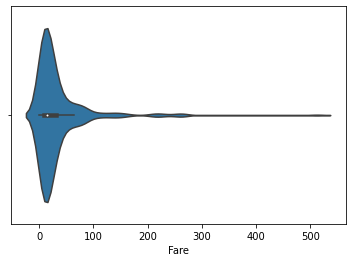

In [24]:
sns.violinplot(data['Fare'])

Most people paid fare less than 50 and some even paid 500

##### Bivariate Analysis

<AxesSubplot:xlabel='Sex', ylabel='Survived'>

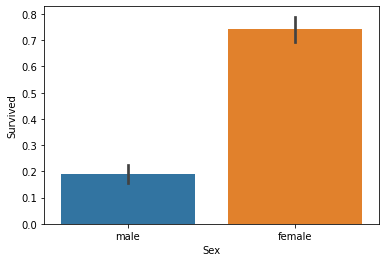

In [25]:
sns.barplot(x=df['Sex'],y=df['Survived'])

More than 70% women survived and less than 20% men survived

<AxesSubplot:xlabel='SibSp', ylabel='Survived'>

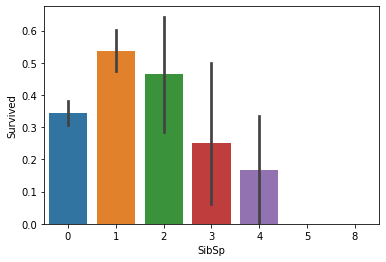

In [26]:
sns.barplot(x='SibSp',y='Survived',data=df)

Survival rate of passengers having one sibling or spouse was maximum.

<AxesSubplot:xlabel='Embarked', ylabel='Survived'>

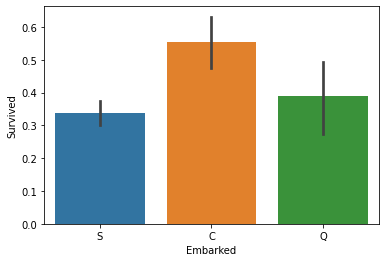

In [27]:
sns.barplot(x='Embarked',y='Survived',data=df)

People boarding from C harbor had most survival rate

<AxesSubplot:xlabel='Pclass', ylabel='Survived'>

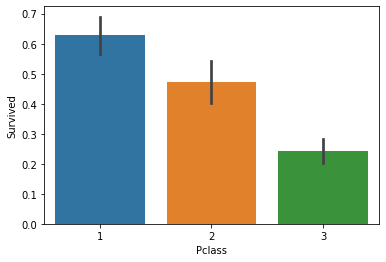

In [28]:
sns.barplot(x='Pclass',y='Survived',data=df)

<AxesSubplot:xlabel='Parch', ylabel='Survived'>

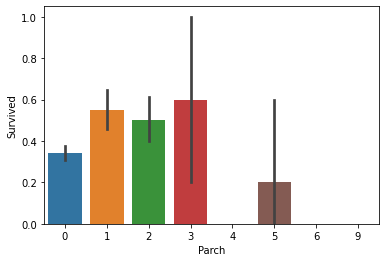

In [29]:
sns.barplot(x='Parch',y='Survived',data=df)

Survival rate of passenges having parents/guardians 1,2 or was more than 50%. Amost none of the passenger survived who had Parch 4 or 5.

##### Multivariate Analysis

<AxesSubplot:xlabel='Age', ylabel='Fare'>

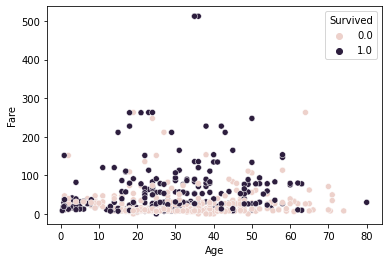

In [30]:
sns.scatterplot(x=df['Age'],y=df['Fare'],hue=df['Survived'])

Passesngers who had paid highe fares have survived the most

<AxesSubplot:xlabel='Pclass', ylabel='Age'>

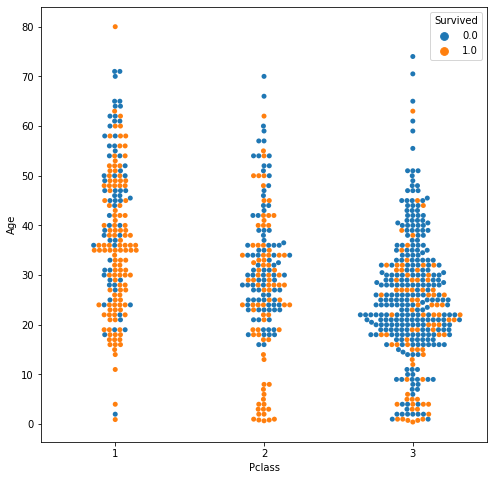

In [31]:
plt.figure(figsize=(8,8))
sns.swarmplot(x=df['Pclass'],y=df['Age'],hue=df['Survived'])

People from 1st class survived the most and almost all the children from 2 class survived while very few passengers survived from 3rd class

<AxesSubplot:xlabel='Sex', ylabel='Age'>

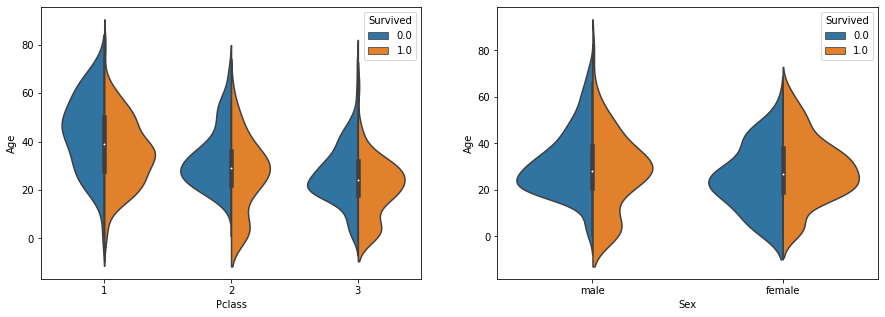

In [32]:
fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

sns.violinplot(x='Pclass', y='Age', hue='Survived', data=df, split=True, ax=ax1)
sns.violinplot(x='Sex', y='Age', hue='Survived', data=df, split=True, ax=ax2)

There are more old people in 1st class, most of the children srom 2nd class survived also children from 3rd also survived. Most male children survived and women from 20 to 40 had much better survival rate.

<Figure size 576x576 with 0 Axes>

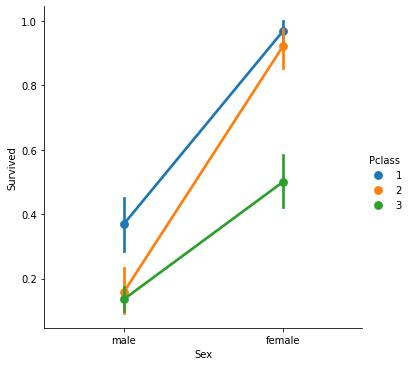

In [33]:
plt.figure(figsize=(8,8))
sns.factorplot(x='Sex', y='Survived', hue='Pclass', data=df)

Almost all Women from 1st and 2nd class survived whereas very few men survived from 1st class and least from 2nd and 3rd classes

<AxesSubplot:>

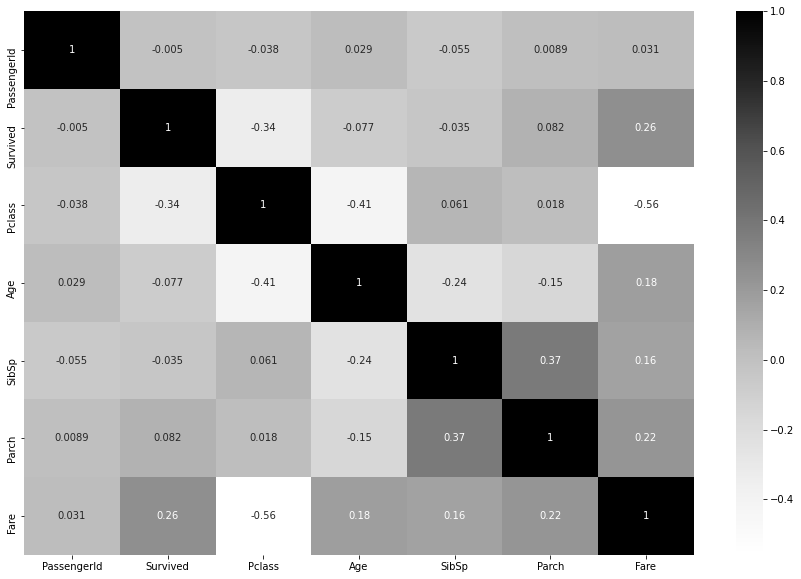

In [34]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),annot=True,cmap='Greys')

Survived feature shows positive correlation with fare paid, and very little with parch column whereas it shows string negative correlation with Pclass.

# Pre-Processing Pipeline

In [35]:
#Extracting titles from Name column
df['Title']=df.Name.str.extract(' ([A-Za-z]+)\.', expand=False)

In [36]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,source,Title
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,train,Mr
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,train,Mrs
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,train,Miss
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,train,Mrs
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,train,Mr


In [37]:
pd.crosstab(df['Title'],df['Sex'])

Sex,female,male
Title,,
Capt,0,1
Col,0,4
Countess,1,0
Don,0,1
Dona,1,0
Dr,1,7
Jonkheer,0,1
Lady,1,0
Major,0,2


Apart from tiles,there aare Mlle, Mme, and Ms we are misspelled

In [38]:
#We replace rarely ocuurling titles with 'rare'
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir',
                                   'Jonkheer', 'Dona'], 'Rare')

In [39]:
df['Title'].value_counts()

Mr        757
Miss      260
Mrs       197
Master     61
Rare       29
Ms          2
Mlle        2
Mme         1
Name: Title, dtype: int64

In [40]:
df['Title'].replace(['Mlle','Ms'],'Miss',inplace=True)
df['Title'].replace('Mme','Mrs',inplace=True)
df['Title'].value_counts()

Mr        757
Miss      264
Mrs       198
Master     61
Rare       29
Name: Title, dtype: int64

##### Filling NaN Values

In [41]:
mean = train["Age"].mean()
std = test["Age"].std()
is_null = df["Age"].isnull().sum()
# compute random numbers between the mean, std and is_null
rand_age = np.random.randint(mean - std, mean + std, size = is_null)
# fill NaN values in Age column with random values generated
age_slice = df["Age"].copy()
age_slice[np.isnan(age_slice)] = rand_age
df["Age"] = age_slice

In [42]:
embarked_mode = train['Embarked'].mode()
df['Embarked'] = df['Embarked'].fillna(embarked_mode)

In [43]:
df['Embarked'].fillna(train['Embarked'].mode()[0],inplace=True)

In [44]:
df.isnull().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          0
source            0
Title             0
dtype: int64

In [45]:
#Since too many null values we drop this column
df.drop('Cabin',axis=1,inplace=True)

In [46]:
#We add another column by adding siblings and parent column
df['Family']=df['SibSp']+df['Parch']

In [47]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,source,Title,Family
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,train,Mr,1
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,train,Mrs,1
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,train,Miss,0
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,train,Mrs,1
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,train,Mr,0


In [48]:
#We drop the identifier columns
df.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)

In [49]:
#we Encode Sex, Embarked and title column
from sklearn.preprocessing import OrdinalEncoder
e=OrdinalEncoder()

In [50]:
df['Sex']=e.fit_transform(df['Sex'].values.reshape(-1,1))
df['Title']=e.fit_transform(df['Title'].values.reshape(-1,1))
df['Embarked']=e.fit_transform(df['Embarked'].values.reshape(-1,1))

****Separating the data frame into train and test¶

In [51]:
train = df.loc[df['source']=='train']
test = df.loc[df['source']=='test']

In [52]:
train.drop('source',axis=1,inplace=True)
test.drop(['source','Survived'],axis=1,inplace=True)

In [53]:
#We separate the data
x=train.iloc[:,1:]
y=train.iloc[:,0]

****Handling Imbalanced Dataset

In [54]:
from imblearn.over_sampling import SMOTE
over=SMOTE()

In [55]:
x,y=over.fit_resample(x,y)

In [56]:
#We scale the independent variables
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

In [57]:
#train dataset
xd=scaler.fit_transform(x)
x=pd.DataFrame(xd,columns=x.columns)

In [58]:
#test dataset
testd=scaler.fit_transform(test)
test=pd.DataFrame(testd,columns=test.columns)

In [59]:
x.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Family
0,1.0,1.0,0.271174,0.125,0.0,0.014151,1.0,0.50,0.1
1,0.0,0.0,0.472229,0.125,0.0,0.139136,0.0,0.75,0.1
2,1.0,0.0,0.321438,0.000,0.0,0.015469,1.0,0.25,0.0
3,0.0,0.0,0.434531,0.125,0.0,0.103644,1.0,0.75,0.1
4,1.0,1.0,0.434531,0.000,0.0,0.015713,1.0,0.50,0.0


In [60]:
test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Family
0,1.0,1.0,0.452723,0.000,0.000000,0.015282,0.5,0.50,0.0
1,1.0,0.0,0.617566,0.125,0.000000,0.013663,1.0,0.75,0.1
2,0.5,1.0,0.815377,0.000,0.000000,0.018909,0.5,0.50,0.0
3,1.0,1.0,0.353818,0.000,0.000000,0.016908,1.0,0.50,0.0
4,1.0,0.0,0.287881,0.125,0.111111,0.023984,1.0,0.75,0.2


# Modelling Phase

In [61]:
#We import Classification Models
from sklearn.naive_bayes import  GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [62]:
from sklearn.model_selection import train_test_split, cross_val_score

In [63]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_auc_score,roc_curve

In [64]:
#Function to find the best random state
def randomstate(x,y):
    maxx=0
    model=LogisticRegression()
    for i in range(1,201):
        xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.25,random_state=i)
        model.fit(xtrain,ytrain)
        p=model.predict(xtest)
        accu=accuracy_score(p,ytest)
        if accu>maxx:
            maxx=accu
            j=i
    return j

In [65]:
#To evakuate performances of all the models
def performance(p,ytest,m,xtest,s):
    print('------------------------------------',m,'------------------------------------')
    print('Accuracy',np.round(accuracy_score(p,ytest),4))
    print('----------------------------------------------------------')
    print('Mean of Cross Validation Score',np.round(s.mean(),4))
    print('----------------------------------------------------------')
    print('AUC_ROC Score',np.round(roc_auc_score(ytest,m.predict_proba(xtest)[:,1]),4))
    print('----------------------------------------------------------')
    print('Confusion Matrix')
    print(confusion_matrix(p,ytest))
    print('----------------------------------------------------------')
    print('Classification Report')
    print(classification_report(p,ytest))

In [66]:
models=[GaussianNB(),KNeighborsClassifier(),SVC(probability=True),LogisticRegression(),DecisionTreeClassifier(),
        RandomForestClassifier(),AdaBoostClassifier(),GradientBoostingClassifier(),XGBClassifier(verbosity=0)]

In [67]:
#Creates and trains model from the models list
def createmodel(trainx,testx,trainy,testy):
    for i in models:
        model=i
        model.fit(trainx,trainy)
        p=model.predict(testx)
        score=cross_val_score(model,x,y,cv=10)
        performance(p,testy,model,testx,score)
        

In [68]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.25,random_state=randomstate(x,y))
createmodel(xtrain,xtest,ytrain,ytest)

------------------------------------ GaussianNB() ------------------------------------
Accuracy 0.8291
----------------------------------------------------------
Mean of Cross Validation Score 0.7997
----------------------------------------------------------
AUC_ROC Score 0.899
----------------------------------------------------------
Confusion Matrix
[[122  19]
 [ 28 106]]
----------------------------------------------------------
Classification Report
              precision    recall  f1-score   support

         0.0       0.81      0.87      0.84       141
         1.0       0.85      0.79      0.82       134

    accuracy                           0.83       275
   macro avg       0.83      0.83      0.83       275
weighted avg       0.83      0.83      0.83       275

------------------------------------ KNeighborsClassifier() ------------------------------------
Accuracy 0.8655
----------------------------------------------------------
Mean of Cross Validation Score 0.8216
----

Almost all models are giving same performance, still top performing models are SVC, AdaBoost, Random Forest, XGBoost and Gradient Boost. So we apply Hyperparameter tuning on them

# Hyperparameter Tuning

In [69]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.25,random_state=randomstate(x,y))

##### Ada Boost

In [70]:
params={'base_estimator':[SVC(),LogisticRegression(),DecisionTreeClassifier()],
      'n_estimators':[50, 100, 150, 200, 250, 300],
      'learning_rate':[0.0001,0.001,0.01,0.1,]}

In [71]:
g=GridSearchCV(AdaBoostClassifier(),params,cv=10)

In [72]:
g.fit(xtrain,ytrain)

GridSearchCV(cv=10, estimator=AdaBoostClassifier(),
             param_grid={'base_estimator': [SVC(), LogisticRegression(),
                                            DecisionTreeClassifier()],
                         'learning_rate': [0.0001, 0.001, 0.01, 0.1],
                         'n_estimators': [50, 100, 150, 200, 250, 300]})

In [73]:
print(g.best_params_)
print(g.best_score_)
print(g.best_estimator_)

{'base_estimator': DecisionTreeClassifier(), 'learning_rate': 0.1, 'n_estimators': 250}
0.7981633852483103
AdaBoostClassifier(base_estimator=DecisionTreeClassifier(), learning_rate=0.1,
                   n_estimators=250)


In [74]:
m=AdaBoostClassifier(base_estimator=DecisionTreeClassifier(), learning_rate=0.1,n_estimators=250)
m.fit(xtrain,ytrain)
p=m.predict(xtest)
score=cross_val_score(m,x,y,cv=10)
performance(p,ytest,m,xtest,score)

------------------------------------ AdaBoostClassifier(base_estimator=DecisionTreeClassifier(), learning_rate=0.1,
                   n_estimators=250) ------------------------------------
Accuracy 0.8509
----------------------------------------------------------
Mean of Cross Validation Score 0.8216
----------------------------------------------------------
AUC_ROC Score 0.894
----------------------------------------------------------
Confusion Matrix
[[124  15]
 [ 26 110]]
----------------------------------------------------------
Classification Report
              precision    recall  f1-score   support

         0.0       0.83      0.89      0.86       139
         1.0       0.88      0.81      0.84       136

    accuracy                           0.85       275
   macro avg       0.85      0.85      0.85       275
weighted avg       0.85      0.85      0.85       275



##### Random Forest

In [75]:
params={'n_estimators':[100, 200, 300, 400, 500],
            'criterion':['gini','entropty'],
            'max_depth':[None,1,2,3,4,5,6,7,8,9,10,15,20,25,30,35,40],
           'max_features':['int','float','auto','log2']}

In [76]:
g=GridSearchCV(RandomForestClassifier(),params,cv=10)

In [77]:
g.fit(xtrain,ytrain)

GridSearchCV(cv=10, estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropty'],
                         'max_depth': [None, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15,
                                       20, 25, 30, 35, 40],
                         'max_features': ['int', 'float', 'auto', 'log2'],
                         'n_estimators': [100, 200, 300, 400, 500]})

In [78]:
print(g.best_params_)
print(g.best_score_)
print(g.best_estimator_)

{'criterion': 'gini', 'max_depth': 7, 'max_features': 'auto', 'n_estimators': 400}
0.8420070526006465
RandomForestClassifier(max_depth=7, n_estimators=400)


In [79]:
m=RandomForestClassifier(max_depth=7, n_estimators=400)
m.fit(xtrain,ytrain)
p=m.predict(xtest)
score=cross_val_score(m,x,y,cv=10)
performance(p,ytest,m,xtest,score)

------------------------------------ RandomForestClassifier(max_depth=7, n_estimators=400) ------------------------------------
Accuracy 0.8764
----------------------------------------------------------
Mean of Cross Validation Score 0.8462
----------------------------------------------------------
AUC_ROC Score 0.9423
----------------------------------------------------------
Confusion Matrix
[[132  16]
 [ 18 109]]
----------------------------------------------------------
Classification Report
              precision    recall  f1-score   support

         0.0       0.88      0.89      0.89       148
         1.0       0.87      0.86      0.87       127

    accuracy                           0.88       275
   macro avg       0.88      0.88      0.88       275
weighted avg       0.88      0.88      0.88       275



##### XGBoost

In [80]:
params={
 "learning_rate"    : [0.01,0.05, 0.10] ,
 "max_depth"        : [ 3, 4, 5, 6, 8, 10, 12, 15,20,25,30,35,40,None],
 "min_child_weight" : [ 1, 3, 5, 7 ],
 "gamma"            : [ 0.0, 0.1, 0.2 , 0.3, 0.4 ],
 "colsample_bytree" : [ 0.3, 0.4, 0.5 , 0.7 ]
    
}

In [81]:
g=GridSearchCV(XGBClassifier(),params,cv=10)

In [82]:
g.fit(xtrain,ytrain)

GridSearchCV(cv=10,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, gamma=None,
                                     gpu_id=None, importance_type='gain',
                                     interaction_constraints=None,
                                     learning_rate=None, max_delta_step=None,
                                     max_depth=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     n_estimators=100, n_job...
                                     num_parallel_tree=None, random_state=None,
                                     reg_alpha=None, reg_lambda=None,
                                     scale_pos_weight=None, subsample=None,
                                     tree_method=None, va

In [83]:
print(g.best_params_)
print(g.best_score_)
print(g.best_estimator_)

{'colsample_bytree': 0.4, 'gamma': 0.4, 'learning_rate': 0.05, 'max_depth': 12, 'min_child_weight': 1}
0.8456068175139583
XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=0.4, gamma=0.4, gpu_id=-1,
              importance_type='gain', interaction_constraints='',
              learning_rate=0.05, max_delta_step=0, max_depth=12,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=100, n_jobs=4, num_parallel_tree=1, random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
              tree_method='exact', validate_parameters=1, verbosity=None)


In [84]:
m=XGBClassifier(colsample_bytree=0.4, gamma=0.4, learning_rate=0.05, max_depth= 12, min_child_weight= 1)
m.fit(xtrain,ytrain)
p=m.predict(xtest)
score=cross_val_score(m,x,y,cv=10)
performance(p,ytest,m,xtest,score)

------------------------------------ XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=0.4, gamma=0.4, gpu_id=-1,
              importance_type='gain', interaction_constraints='',
              learning_rate=0.05, max_delta_step=0, max_depth=12,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=100, n_jobs=4, num_parallel_tree=1, random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
              tree_method='exact', validate_parameters=1, verbosity=None) ------------------------------------
Accuracy 0.9091
----------------------------------------------------------
Mean of Cross Validation Score 0.8508
----------------------------------------------------------
AUC_ROC Score 0.9539
----------------------------------------------------------
Confusion Matrix
[[137  12]
 [ 13 113]]
------------------------------------------------------

We choose XGBClassifier as our final model which seems to give the best mean cross validation score

### Finalizing the model

In [85]:
model=XGBClassifier(colsample_bytree=0.4, gamma=0.4, learning_rate=0.05, max_depth= 12, min_child_weight= 1)
model.fit(xtrain,ytrain)
p=model.predict(xtest)
score=cross_val_score(model,x,y,cv=10)

### Evaluation Metrics

In [86]:
performance(p,ytest,model,xtest,score)

------------------------------------ XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=0.4, gamma=0.4, gpu_id=-1,
              importance_type='gain', interaction_constraints='',
              learning_rate=0.05, max_delta_step=0, max_depth=12,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=100, n_jobs=4, num_parallel_tree=1, random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
              tree_method='exact', validate_parameters=1, verbosity=None) ------------------------------------
Accuracy 0.9091
----------------------------------------------------------
Mean of Cross Validation Score 0.8508
----------------------------------------------------------
AUC_ROC Score 0.9539
----------------------------------------------------------
Confusion Matrix
[[137  12]
 [ 13 113]]
------------------------------------------------------

In [87]:
fpred=pd.Series(model.predict_proba(xtest)[:,1])
fpr,tpr,threshold=roc_curve(ytest,fpred)

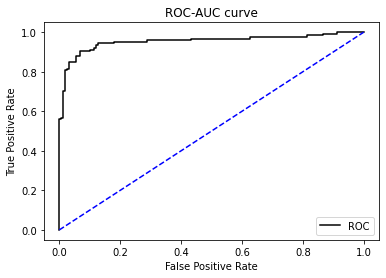

In [88]:
plt.plot(fpr,tpr,color='k',label='ROC')
plt.plot([0,1],[0,1],color='b',linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC curve')
plt.legend()

### Predicting the Test dataset

In [89]:
predictions=model.predict(test)

In [90]:
predictions=pd.DataFrame(predictions,columns=['Survived'])

In [91]:
predictions.head()

,Survived
0,0.0
1,0.0
2,0.0
3,0.0
4,1.0


In [93]:
predictions['Survived']=predictions['Survived'].apply(lambda x: int(x))

In [94]:
predictions.head()

,Survived
0,0
1,0
2,0
3,0
4,1


In [95]:
predictions.to_csv('test_predictions.csv')